# Titanic - Machine Learning from Disaster

Predict the survival of RMS Titanic passengers using passenger data (name, age, gender, socio-economic class, etc.).

**Evaluation metric:** Accuracy (percentage of correctly predicted passengers).

**Files:** `train.csv` (891 passengers + `Survived` label), `test.csv` (418 passengers without labels).

## Objectives

- Exploratory data analysis (EDA) to understand survival patterns.
- Feature engineering: extract `Title`, `FamilySize`, `IsAlone`, `Deck`, impute `Age` & `Embarked`.
- Compare several classification models with cross-validation.
- Build an ensemble (voting) for the best accuracy.
- Generate the `submission.csv` file.

In [17]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              VotingClassifier, ExtraTreesClassifier)
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [3]:
import os

# Ensure we read data from the notebook's own directory
DATA_DIR = os.path.dirname(os.path.abspath('__file__')) or os.getcwd()
if not os.path.exists(os.path.join(DATA_DIR, 'train.csv')):
    DATA_DIR = '/run/media/bugs/Data/Febriyansyah-Other/Project/github-repo/NOTEBOOK-KAGGLE/CLASSIFICATION/titanic-survival'

train = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
test = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))
submission = pd.read_csv(os.path.join(DATA_DIR, 'gender_submission.csv'))

print(f'Data directory: {DATA_DIR}')
print(f'train shape: {train.shape}')
print(f'test shape:  {test.shape}')
print(f'submission shape: {submission.shape}')
print('\ntrain columns:', list(train.columns))
print('test columns: ', list(test.columns))

Data directory: /run/media/bugs/Data/Febriyansyah-Other/Project/github-repo/NOTEBOOK-KAGGLE/CLASSIFICATION/titanic-survival
train shape: (891, 12)
test shape:  (418, 11)
submission shape: (418, 2)

train columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
test columns:  ['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


=== Missing values (train) ===
Age         177
Cabin       687
Embarked      2
dtype: int64

=== Missing values (test) ===
Age       86
Fare       1
Cabin    327
dtype: int64

=== Survived distribution ===
Survived
0    0.616
1    0.384
Name: proportion, dtype: float64


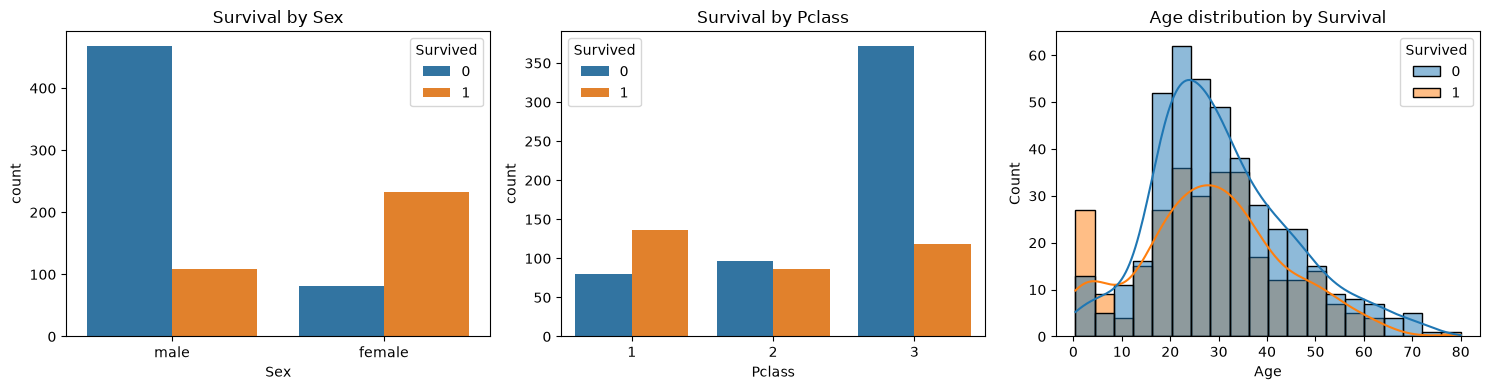

In [4]:
print('=== Missing values (train) ===')
print(train.isna().sum()[train.isna().sum() > 0])
print('\n=== Missing values (test) ===')
print(test.isna().sum()[test.isna().sum() > 0])

print('\n=== Survived distribution ===')
print(train['Survived'].value_counts(normalize=True).round(3))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(data=train, x='Sex', hue='Survived', ax=axes[0])
axes[0].set_title('Survival by Sex')
sns.countplot(data=train, x='Pclass', hue='Survived', ax=axes[1])
axes[1].set_title('Survival by Pclass')
sns.histplot(data=train, x='Age', hue='Survived', kde=True, ax=axes[2])
axes[2].set_title('Age distribution by Survival')
plt.tight_layout()
plt.show()

In [5]:
def engineer_features(df):
    """Feature engineering applied identically to train & test."""
    df = df.copy()

    # 1. Title from Name
    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr',
                   'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
    df['Title'] = df['Title'].replace(rare_titles, 'Rare')
    df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

    # 2. Family size & alone flag
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

    # 3. Cabin deck
    df['Deck'] = df['Cabin'].str[0]
    df['Deck'] = df['Deck'].fillna('U')

    # 4. Fare binning (log transform to reduce skew)
    df['Fare_log'] = np.log1p(df['Fare'])

    # 5. Age imputation by Title median
    df['Age'] = df.groupby('Title')['Age'].transform(
        lambda x: x.fillna(x.median()))

    # 6. Embarked imputation (most frequent)
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

    # 7. Fare imputation (single missing value in test)
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())
    df['Fare_log'] = np.log1p(df['Fare'])

    return df


train_fe = engineer_features(train)
test_fe = engineer_features(test)

print('Missing values after engineering (train):', int(train_fe.isna().sum().sum()))
print('Missing values after engineering (test): ', int(test_fe.isna().sum().sum()))
print('\nTitle distribution:')
print(train_fe['Title'].value_counts())
print('\nDeck distribution:')
print(train_fe['Deck'].value_counts())

Missing values after engineering (train): 687
Missing values after engineering (test):  327

Title distribution:
Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

Deck distribution:
Deck
U    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64


In [6]:
FEATURES = ['Pclass', 'Sex', 'Age', 'Fare_log', 'FamilySize', 'IsAlone',
            'Title', 'Deck', 'Embarked']

X = train_fe[FEATURES]
y = train_fe['Survived']
X_test = test_fe[FEATURES]

numeric_features = ['Age', 'Fare_log', 'FamilySize']
categorical_features = ['Pclass', 'Sex', 'IsAlone', 'Title', 'Deck', 'Embarked']

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]), numeric_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ]), categorical_features),
])

print('Features:', FEATURES)
print(f'X shape: {X.shape}, X_test shape: {X_test.shape}')

Features: ['Pclass', 'Sex', 'Age', 'Fare_log', 'FamilySize', 'IsAlone', 'Title', 'Deck', 'Embarked']
X shape: (891, 9), X_test shape: (418, 9)


In [14]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(n_estimators=500, random_state=RANDOM_STATE),
    'ExtraTrees': ExtraTreesClassifier(n_estimators=500, random_state=RANDOM_STATE),
    'GradientBoosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'SVC': CalibratedClassifierCV(SVC(random_state=RANDOM_STATE), ensemble=False),
    'XGBoost': XGBClassifier(n_estimators=500, learning_rate=0.05, random_state=RANDOM_STATE,
                             eval_metric='logloss'),
    'LightGBM': LGBMClassifier(n_estimators=500, learning_rate=0.05, random_state=RANDOM_STATE,
                               verbose=-1),
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
results = {}

for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', model)])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    results[name] = scores.mean()
    print(f'{name:22s} CV accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})')

best = max(results, key=results.get)
print(f'\nBest single model: {best} ({results[best]:.4f})')

LogisticRegression     CV accuracy: 0.8271 (+/- 0.0329)
RandomForest           CV accuracy: 0.8125 (+/- 0.0300)
ExtraTrees             CV accuracy: 0.7867 (+/- 0.0244)
GradientBoosting       CV accuracy: 0.8383 (+/- 0.0317)
SVC                    CV accuracy: 0.8305 (+/- 0.0270)
XGBoost                CV accuracy: 0.8193 (+/- 0.0236)
LightGBM               CV accuracy: 0.8092 (+/- 0.0368)

Best single model: GradientBoosting (0.8383)


In [15]:
# Ensemble: soft voting of the best models
voting = VotingClassifier(estimators=[
    ('xgb', XGBClassifier(n_estimators=500, learning_rate=0.05, random_state=RANDOM_STATE,
                          eval_metric='logloss')),
    ('lgbm', LGBMClassifier(n_estimators=500, learning_rate=0.05, random_state=RANDOM_STATE,
                            verbose=-1)),
    ('rf', RandomForestClassifier(n_estimators=500, random_state=RANDOM_STATE)),
    ('gb', GradientBoostingClassifier(random_state=RANDOM_STATE)),
    ('svc', CalibratedClassifierCV(SVC(random_state=RANDOM_STATE), ensemble=False)),
], voting='soft', n_jobs=-1)

voting_pipe = Pipeline([('prep', preprocessor), ('clf', voting)])
voting_scores = cross_val_score(voting_pipe, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
print(f'Voting ensemble CV accuracy: {voting_scores.mean():.4f} (+/- {voting_scores.std():.4f})')

Voting ensemble CV accuracy: 0.8372 (+/- 0.0234)


In [16]:
# Fit the ensemble on all training data and predict test set
voting_pipe.fit(X, y)
test_pred = voting_pipe.predict(X_test)

out = pd.DataFrame({'PassengerId': test_fe['PassengerId'], 'Survived': test_pred})
out_path = os.path.join(DATA_DIR, 'submission.csv')
out.to_csv(out_path, index=False)

print(f'Submission saved to {out_path}')
print(out['Survived'].value_counts())
print('\nFirst rows:')
print(out.head(10))

Submission saved to /run/media/bugs/Data/Febriyansyah-Other/Project/github-repo/NOTEBOOK-KAGGLE/CLASSIFICATION/titanic-survival/submission.csv
Survived
0    271
1    147
Name: count, dtype: int64

First rows:
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
5          897         0
6          898         0
7          899         0
8          900         1
9          901         0


## Summary

- **EDA:** Females and 1st-class passengers had higher survival rates.
- **Feature engineering:** `Title`, `FamilySize`, `IsAlone`, `Deck`, imputed `Age` & `Embarked`.
- **Model:** Voting ensemble (XGBoost + LightGBM + RandomForest + GradientBoosting + SVC) with soft voting.
- **Output:** `submission.csv` containing `PassengerId` and `Survived` (418 rows) — ready to submit to Kaggle.

To submit: open the **Submit Prediction** tab on the competition page and upload `submission.csv`.